In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# To display plots properly
%matplotlib inline


In [3]:
df=pd.read_csv("Dataset.csv")

# *Exploratory Data Analysis*

In [4]:
#Basic dataset Information

## Schema and Size
## Datatypes

rows, cols = df.shape
print(f"The dataset contains {rows} rows and {cols} columns.") #returns no.of rows and columns
df.columns  #returns what are the columns present in the dataset
print(df.dtypes)  #returns the datatypes

The dataset contains 9712 rows and 8 columns.
Age                                    int64
Gender                                   str
Avg_Daily_Screen_Time_hr             float64
Primary_Device                           str
Exceeded_Recommended_Limit              bool
Educational_to_Recreational_Ratio    float64
Health_Impacts                           str
Urban_or_Rural                           str
dtype: object


#### ****Null Handling****

In [5]:
#check missing values

## Null Handling

# Check missing values
print(df.isnull().sum())

# Replace missing values
df['Health_Impacts'] = df['Health_Impacts'].fillna('No Health Impact')

# Check again
print(df.isnull().sum())

# Display data
print(df.head())

Age                                     0
Gender                                  0
Avg_Daily_Screen_Time_hr                0
Primary_Device                          0
Exceeded_Recommended_Limit              0
Educational_to_Recreational_Ratio       0
Health_Impacts                       3218
Urban_or_Rural                          0
dtype: int64
Age                                  0
Gender                               0
Avg_Daily_Screen_Time_hr             0
Primary_Device                       0
Exceeded_Recommended_Limit           0
Educational_to_Recreational_Ratio    0
Health_Impacts                       0
Urban_or_Rural                       0
dtype: int64
   Age  Gender  Avg_Daily_Screen_Time_hr Primary_Device  \
0   14    Male                      3.99     Smartphone   
1   11  Female                      4.61         Laptop   
2   18  Female                      3.73             TV   
3   15  Female                      1.21         Laptop   
4   12  Female                 

In [6]:
 #Verification of Categorical Consistencies

## Inconsistent Categories

print(df['Gender'].unique())
print(df['Primary_Device'].unique())
print(df['Exceeded_Recommended_Limit'].unique())
print(df['Urban_or_Rural'].unique())

<StringArray>
['Male', 'Female']
Length: 2, dtype: str
<StringArray>
['Smartphone', 'Laptop', 'TV', 'Tablet']
Length: 4, dtype: str
[ True False]
<StringArray>
['Urban', 'Rural']
Length: 2, dtype: str


In [7]:
## Handling Multi-label Categorical Column

df['Health_Impacts'].str.split(', ').explode().value_counts()

Health_Impacts
Poor Sleep          4868
No Health Impact    3218
Eye Strain          2382
Anxiety             1605
Obesity Risk        1217
Name: count, dtype: int64

# ****New Derivations****

In [8]:
##Creating Age Bands

def age_band(age):
    
    if age <= 9:
        return "Child"  ##5-9 as "Child"
    elif age <= 13:
        return "Pre-Teen" ##10-13 as "Pre-Teen"
    elif age <= 16:
        return "Teen"  ##14-16 as "Teen"
    elif age<=18:
        return "Senior Teen"  ## 17-18 as "Senior Teen"
    else:
        return "Out of Range" ## incase of Outliers

df["Age_Band"] = df["Age"].apply(age_band)

def screen_time_category(hours):
    if hours <= 2:
        return "Low"
    elif hours <= 4:
        return "Moderate"
    elif hours <= 6:
        return "High"
    else:
        return "Very High"

df["Screen_Time_Category"] = df["Avg_Daily_Screen_Time_hr"].apply(screen_time_category)


def device_type_category(device):
    if device in ["Smartphone", "Tablet", "Laptop"]:
        return "Portable"
    elif device in ["Desktop", "Smart TV"]:
        return "Wall-Mounted"
    else:
        return "Other"

df["Device_Type_Category"] = df["Primary_Device"].apply(device_type_category)


def usage_balance_category(ratio):
    if ratio < 0.5:
        return "Mostly Recreational"
    elif 0.5 <= ratio <= 1:
        return "Balanced"
    else:
        return "Mostly Educational"

df["Usage_Balance_Category"] = df["Educational_to_Recreational_Ratio"].apply(usage_balance_category)


def health_risk_level(impact):
    if pd.isna(impact) or impact == "None":
        return "No Risk"
    issues = str(impact).split(",")
    if len(issues) == 1:
        return "Moderate Risk"
    else:
        return "High Risk"

df["Health_Risk_Level"] = df["Health_Impacts"].apply(health_risk_level)


def calculate_edu_time(row):
    ratio = row["Educational_to_Recreational_Ratio"]
    total = row["Avg_Daily_Screen_Time_hr"]
    
    return (ratio * total) / (1 + ratio)

df["Educational_Time_hr"] = df.apply(calculate_edu_time, axis=1)
df["Educational_Time_hr"] = df["Educational_Time_hr"].round(3)


def calculate_rec_time(row):
    ratio = row["Educational_to_Recreational_Ratio"]
    total = row["Avg_Daily_Screen_Time_hr"]
    
    return total / (1 + ratio)

def convert_to_actual_time(decimal_hours):
    hours = int(decimal_hours)
    minutes = round((decimal_hours - hours) * 60)
    return f"{hours} hr {minutes} min"

df["Educational_Time_hr"] = df["Avg_Daily_Screen_Time_hr"] * df["Educational_to_Recreational_Ratio"] / (1 + df["Educational_to_Recreational_Ratio"])
df["Recreational_Time_hr"] = df["Avg_Daily_Screen_Time_hr"] - df["Educational_Time_hr"]

df["Educational_Time_Actual"] = df["Educational_Time_hr"].apply(convert_to_actual_time)
df["Recreational_Time_Actual"] = df["Recreational_Time_hr"].apply(convert_to_actual_time)

df[["Educational_Time_hr", "Educational_Time_Actual",
    "Recreational_Time_hr", "Recreational_Time_Actual"]].head()
df

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural,Age_Band,Screen_Time_Category,Device_Type_Category,Usage_Balance_Category,Health_Risk_Level,Educational_Time_hr,Recreational_Time_hr,Educational_Time_Actual,Recreational_Time_Actual
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban,Teen,Moderate,Portable,Mostly Recreational,High Risk,1.180141,2.809859,1 hr 11 min,2 hr 49 min
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban,Pre-Teen,High,Portable,Mostly Recreational,Moderate Risk,1.063846,3.546154,1 hr 4 min,3 hr 33 min
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban,Senior Teen,Moderate,Other,Mostly Recreational,Moderate Risk,0.904242,2.825758,0 hr 54 min,2 hr 50 min
3,15,Female,1.21,Laptop,False,0.39,No Health Impact,Urban,Teen,Low,Portable,Mostly Recreational,Moderate Risk,0.339496,0.870504,0 hr 20 min,0 hr 52 min
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban,Pre-Teen,High,Portable,Mostly Recreational,High Risk,1.936980,3.953020,1 hr 56 min,3 hr 57 min
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9707,17,Male,3.26,Smartphone,True,0.44,Poor Sleep,Urban,Senior Teen,Moderate,Portable,Mostly Recreational,Moderate Risk,0.996111,2.263889,0 hr 60 min,2 hr 16 min
9708,17,Female,4.43,Smartphone,True,0.40,Poor Sleep,Rural,Senior Teen,High,Portable,Mostly Recreational,Moderate Risk,1.265714,3.164286,1 hr 16 min,3 hr 10 min
9709,16,Male,5.62,Smartphone,True,0.39,"Poor Sleep, Eye Strain, Anxiety",Rural,Teen,High,Portable,Mostly Recreational,High Risk,1.576835,4.043165,1 hr 35 min,4 hr 3 min
9710,17,Male,5.60,TV,True,0.43,Poor Sleep,Urban,Senior Teen,High,Other,Mostly Recreational,Moderate Risk,1.683916,3.916084,1 hr 41 min,3 hr 55 min


In [9]:
df.to_csv("Cleaned_Dataset_ScreenSense.csv", index=False)

## **Univariate Analysis**
# *Numerical Values*

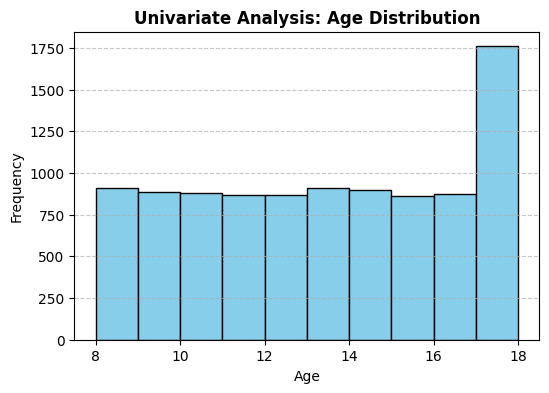

In [16]:
plt.figure(figsize=(6,4))
plt.hist(df["Age"], bins=10, color='skyblue', edgecolor='black')
plt.title("Univariate Analysis: Age Distribution", fontsize=12, fontweight='bold')
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 🔍 Insight:
- The age distribution is fairly uniform across the range, with a slight concentration in higher age values.
- Most students fall within the teenage group, indicating the dataset is focused on adolescents.

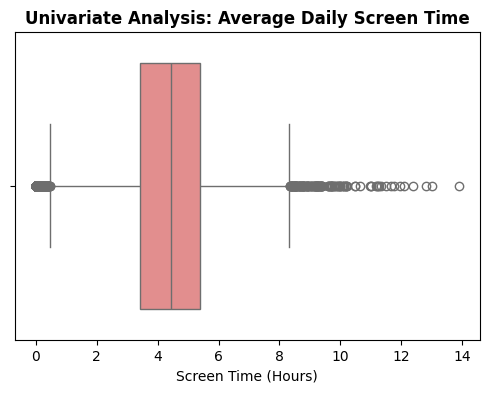

In [17]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Avg_Daily_Screen_Time_hr"], color='lightcoral')
plt.title("Univariate Analysis: Average Daily Screen Time", fontsize=12, fontweight='bold')
plt.xlabel("Screen Time (Hours)")
plt.show()

### 🔍 Insight:
- The median screen time is around 4–5 hours per day.
- Several high-value outliers are present, indicating that some students spend excessive time on screens.
- The distribution is right-skewed, showing more extreme high usage than low usage.

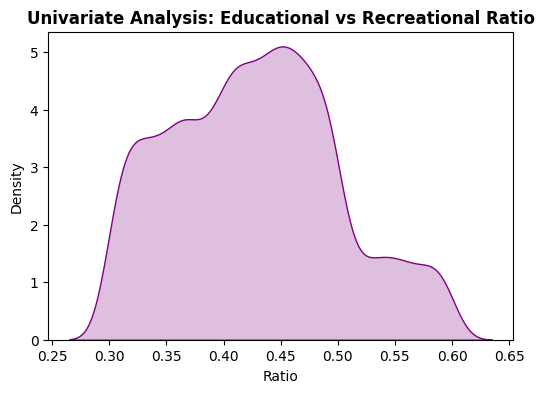

In [18]:
plt.figure(figsize=(6,4))
sns.kdeplot(df["Educational_to_Recreational_Ratio"], fill=True, color='purple')
plt.title("Univariate Analysis: Educational vs Recreational Ratio", fontsize=12, fontweight='bold')
plt.xlabel("Ratio")
plt.show()


### 🔍 Insight:
- The ratio is concentrated between 0.35 and 0.5, indicating a higher inclination towards recreational usage.
- The distribution is slightly skewed, suggesting fewer students prioritize educational screen time.

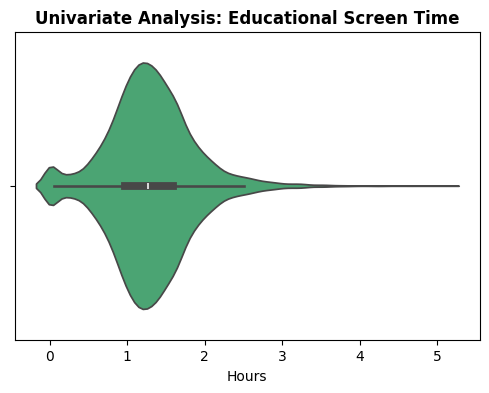

In [19]:
plt.figure(figsize=(6,4))
sns.violinplot(x=df["Educational_Time_hr"], color='mediumseagreen')
plt.title("Univariate Analysis: Educational Screen Time", fontsize=12, fontweight='bold')
plt.xlabel("Hours")
plt.show()

### 🔍 Insight:
- Most students spend around 1–2 hours on educational activities.
- The distribution is dense in the lower range, indicating limited educational screen usage.
- Very few students exceed higher educational screen time.

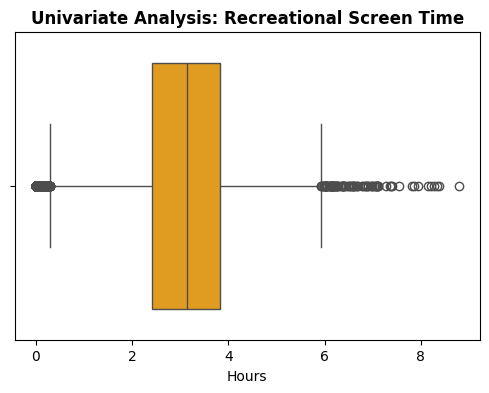

In [20]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Recreational_Time_hr"], color='orange')
plt.title("Univariate Analysis: Recreational Screen Time", fontsize=12, fontweight='bold')
plt.xlabel("Hours")
plt.show()

### 🔍 Insight:
- Recreational screen time has a higher spread compared to educational time.
- The median lies around 2–4 hours, but there are many high-value outliers.
- This indicates that recreational usage dominates and varies significantly among students.

# *Categorical Values*

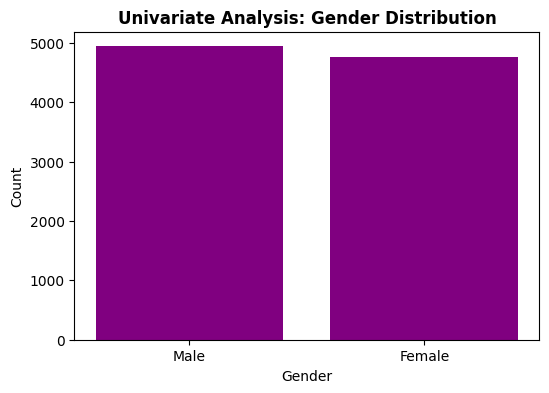

In [56]:
counts = df["Gender"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values, color='purple')
plt.title("Univariate Analysis: Gender Distribution", fontweight='bold')
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

### 🔍 Insight:
- The dataset shows a nearly balanced distribution between male and female students.
- This indicates that the analysis is not biased toward a particular gender.

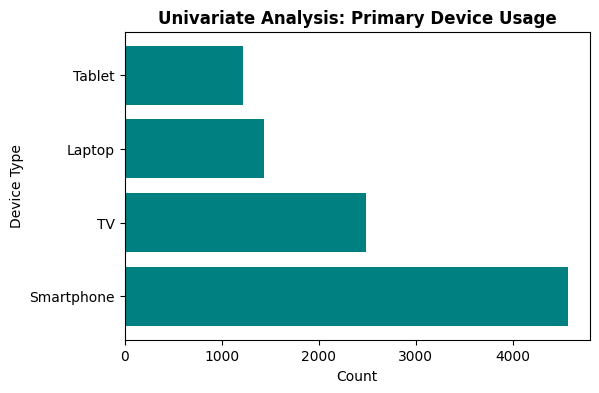

In [24]:
counts = df["Primary_Device"].value_counts()

plt.figure(figsize=(6,4))
plt.barh(counts.index, counts.values, color='teal')
plt.title("Univariate Analysis: Primary Device Usage", fontsize=12, fontweight='bold')
plt.xlabel("Count")
plt.ylabel("Device Type")
plt.show()

### 🔍 Insight:
- Smartphones are the most commonly used device among students by a large margin.
- TV usage is moderate, while laptops and tablets are comparatively less used.
- This highlights the dominance of mobile devices in screen time consumption.

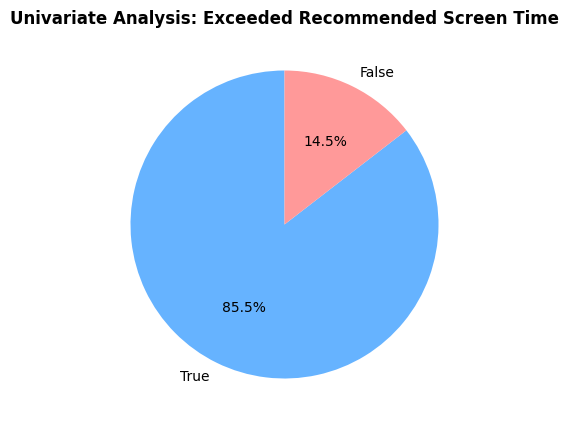

In [25]:
counts = df["Exceeded_Recommended_Limit"].value_counts()

plt.figure(figsize=(5,5))
plt.pie(counts.values, labels=counts.index, autopct="%1.1f%%",
        startangle=90, colors=['#66b3ff','#ff9999'])
plt.title("Univariate Analysis: Exceeded Recommended Screen Time", fontsize=12, fontweight='bold')
plt.show()

### 🔍 Insight:
- A significant majority of students (around 85%) exceed the recommended daily screen time limit.
- Only a small portion stays within healthy usage limits.
- This indicates widespread excessive screen usage among students.

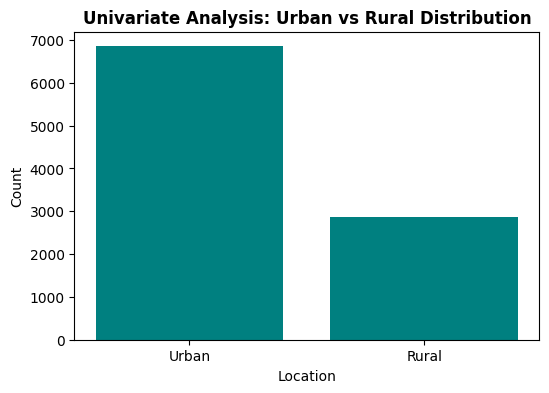

In [54]:
counts = df["Urban_or_Rural"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values, color='teal')
plt.title("Univariate Analysis: Urban vs Rural Distribution", fontweight='bold')
plt.xlabel("Location")
plt.ylabel("Count")
plt.show()

### 🔍 Insight:
- Most students in the dataset belong to urban areas.
- Rural representation is comparatively lower.
- This may indicate a sampling bias or higher screen exposure in urban regions.

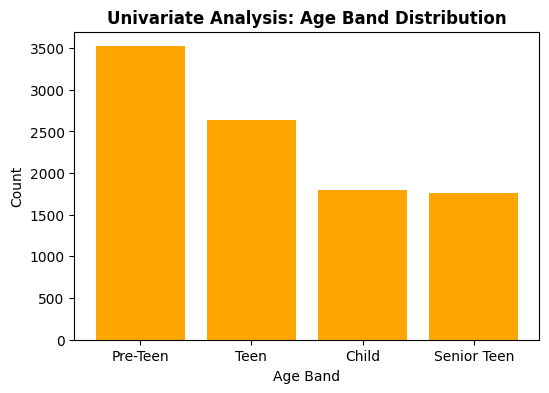

In [55]:
counts = df["Age_Band"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values, color='orange')
plt.title("Univariate Analysis: Age Band Distribution", fontweight='bold')
plt.xlabel("Age Band")
plt.ylabel("Count")
plt.show()

### 🔍 Insight:
- Pre-teen and teen groups form the largest portion of the dataset.
- Child and senior teen groups are comparatively smaller.
- This suggests the dataset is focused mainly on middle age groups.

# *BiVariate Analysis*
### ***Numerical vs Numerical***

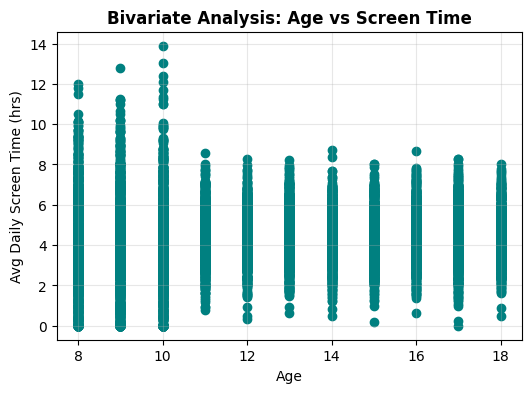

In [30]:
plt.figure(figsize=(6,4))
plt.scatter(df["Age"], df["Avg_Daily_Screen_Time_hr"], color='teal')
plt.xlabel("Age")
plt.ylabel("Avg Daily Screen Time (hrs)")
plt.title("Bivariate Analysis: Age vs Screen Time", fontweight='bold')
plt.grid(alpha=0.3)
plt.show()

### 🔍 Insight:
- There is no strong linear relationship between age and screen time.
- Screen usage is spread across all age groups, with slight clustering in certain age ranges.
- This suggests that screen time is not heavily dependent on age alone.

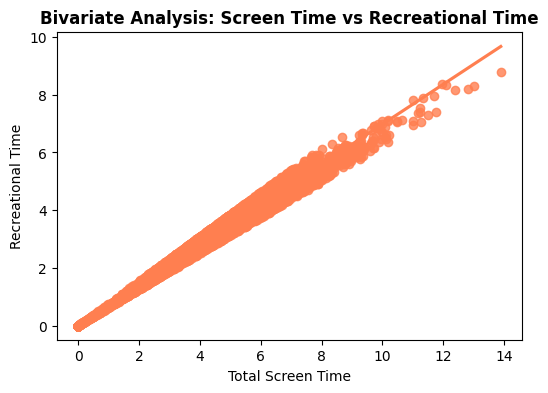

In [31]:
plt.figure(figsize=(6,4))
sns.regplot(
    x=df["Avg_Daily_Screen_Time_hr"],
    y=df["Recreational_Time_hr"],
    color='coral'
)
plt.title("Bivariate Analysis: Screen Time vs Recreational Time", fontweight='bold')
plt.xlabel("Total Screen Time")
plt.ylabel("Recreational Time")
plt.show()

### 🔍 Insight:
- There is a strong positive relationship between total screen time and recreational time.
- As total screen time increases, recreational usage increases almost proportionally.
- This indicates that most screen time is driven by recreational activities.

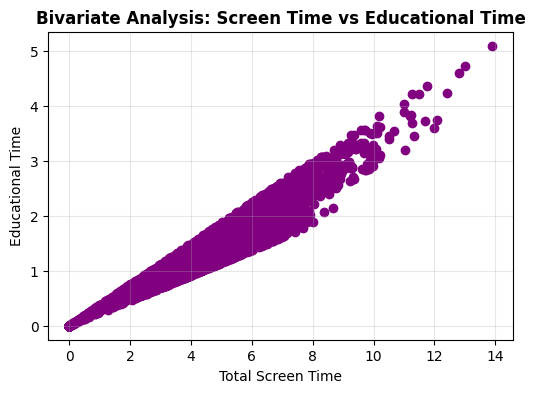

In [32]:
plt.figure(figsize=(6,4))
plt.scatter(df["Avg_Daily_Screen_Time_hr"], df["Educational_Time_hr"], color='purple')
plt.xlabel("Total Screen Time")
plt.ylabel("Educational Time")
plt.title("Bivariate Analysis: Screen Time vs Educational Time", fontweight='bold')
plt.grid(alpha=0.3)
plt.show()

### 🔍 Insight:
- A positive relationship exists between total screen time and educational time, but it is weaker compared to recreational time.
- Educational usage increases with total screen time, but at a slower rate.
- This suggests that additional screen time is more likely spent on recreation than education.

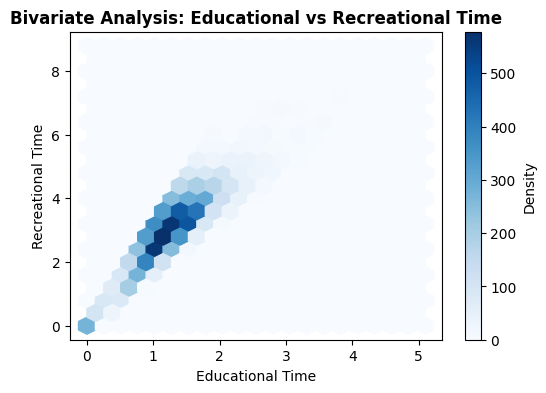

In [34]:
plt.figure(figsize=(6,4))
plt.hexbin(
    df["Educational_Time_hr"],
    df["Recreational_Time_hr"],
    gridsize=20,
    cmap='Blues'
)
plt.xlabel("Educational Time")
plt.ylabel("Recreational Time")
plt.title("Bivariate Analysis: Educational vs Recreational Time", fontweight='bold')
plt.colorbar(label='Density')
plt.show()

### 🔍 Insight:
- There is a moderate positive relationship between educational and recreational time.
- Most data points are concentrated in the lower range of both variables.
- This indicates that students generally spend limited time on both activities, with few high-usage cases.

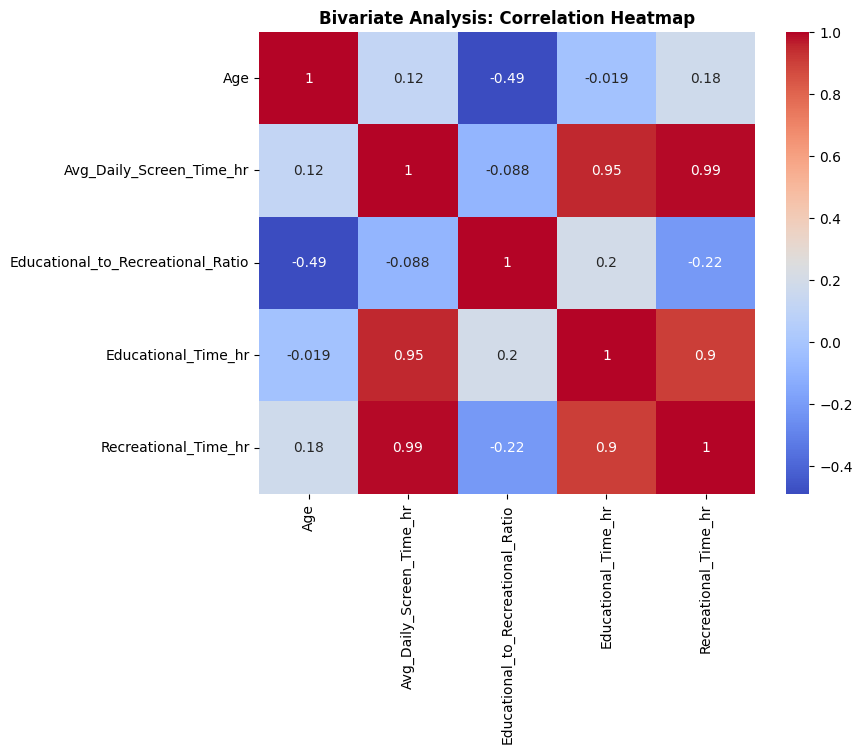

In [35]:
plt.figure(figsize=(8,6))
corr_matrix = df[[
    "Age",
    "Avg_Daily_Screen_Time_hr",
    "Educational_to_Recreational_Ratio",
    "Educational_Time_hr",
    "Recreational_Time_hr"
]].corr()

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Bivariate Analysis: Correlation Heatmap", fontweight='bold')
plt.show()

### 🔍 Insight:
- Recreational time has a very strong positive correlation with total screen time (~0.99).
- Educational time also shows strong correlation with total screen time (~0.95), but slightly lower than recreational.
- Age has weak correlation with screen time, indicating minimal influence.
- Educational-to-recreational ratio shows a negative correlation with age, suggesting balance shifts with age.

### ***Categorical vs Numerical***

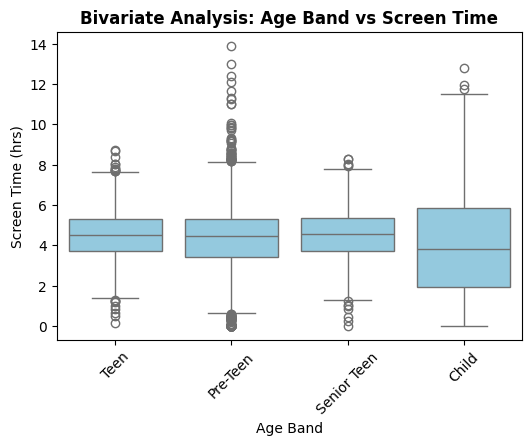

In [50]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Age_Band"], y=df["Avg_Daily_Screen_Time_hr"], color='skyblue')
plt.title("Bivariate Analysis: Age Band vs Screen Time", fontweight='bold')
plt.xlabel("Age Band")
plt.ylabel("Screen Time (hrs)")
plt.xticks(rotation=45)
plt.show()

### 🔍 Insight:
- Screen time is relatively similar across age groups, with slight variation.
- Pre-teens show a wider spread and more high-value outliers.
- Children tend to have slightly lower median screen time compared to teens.

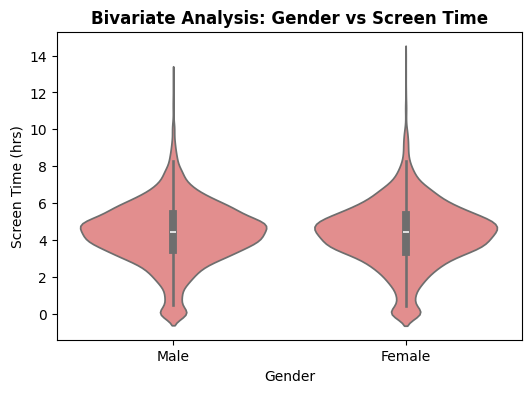

In [51]:
plt.figure(figsize=(6,4))
sns.violinplot(x=df["Gender"], y=df["Avg_Daily_Screen_Time_hr"], color='lightcoral')
plt.title("Bivariate Analysis: Gender vs Screen Time", fontweight='bold')
plt.xlabel("Gender")
plt.ylabel("Screen Time (hrs)")
plt.show()

### 🔍 Insight:
- Screen time distribution is very similar for both males and females.
- There is no significant gender-based difference in screen usage.
- Both groups show similar spread and density patterns.

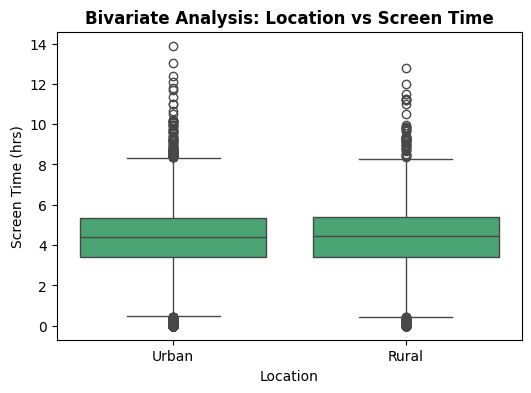

In [52]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Urban_or_Rural"], y=df["Avg_Daily_Screen_Time_hr"], color='mediumseagreen')
plt.title("Bivariate Analysis: Location vs Screen Time", fontweight='bold')
plt.xlabel("Location")
plt.ylabel("Screen Time (hrs)")
plt.show()

### 🔍 Insight:
- Urban and rural students show comparable screen time distributions.
- Urban students have slightly higher variability and more extreme values.
- Overall, location does not strongly influence screen time usage.

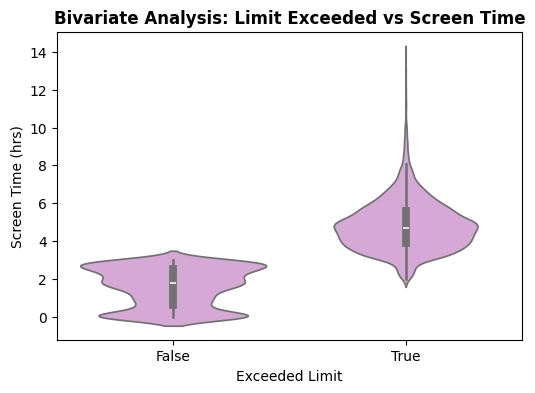

In [53]:
plt.figure(figsize=(6,4))
sns.violinplot(x=df["Exceeded_Recommended_Limit"], y=df["Avg_Daily_Screen_Time_hr"], color='plum')
plt.title("Bivariate Analysis: Limit Exceeded vs Screen Time", fontweight='bold')
plt.xlabel("Exceeded Limit")
plt.ylabel("Screen Time (hrs)")
plt.show()

### 🔍 Insight:
- Students who exceeded the recommended limit have significantly higher screen time.
- Clear separation exists between the two groups.
- This validates that exceeding the limit is directly linked to higher usage.

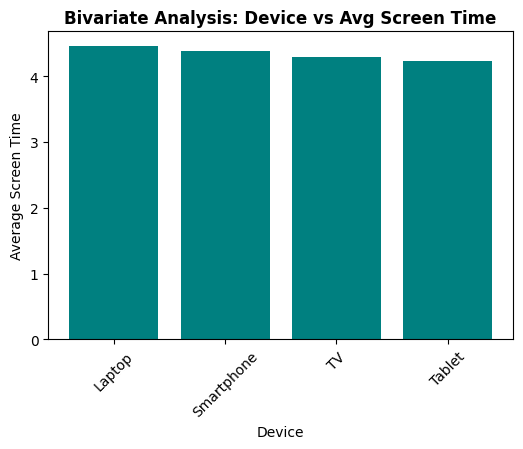

In [43]:
means = df.groupby("Primary_Device")["Avg_Daily_Screen_Time_hr"].mean()

plt.figure(figsize=(6,4))
plt.bar(means.index, means.values, color='teal')
plt.title("Bivariate Analysis: Device vs Avg Screen Time", fontweight='bold')
plt.xlabel("Device")
plt.ylabel("Average Screen Time")
plt.xticks(rotation=45)
plt.show()

### 🔍 Insight:
- Average screen time is similar across all device types.
- Laptop and smartphone users show slightly higher average usage.
- Device type alone does not drastically influence total screen time.

### ***Categorical vs Categorical***

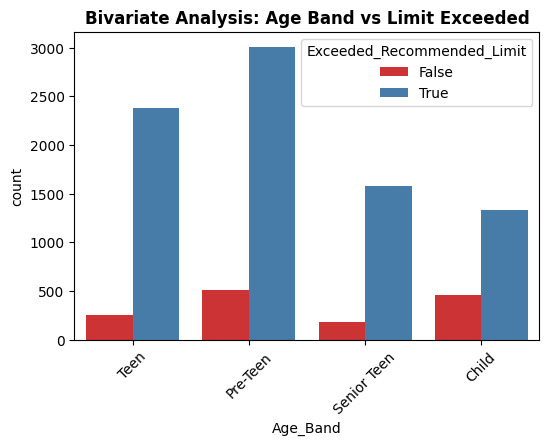

In [45]:
plt.figure(figsize=(6,4))
sns.countplot(x=df["Age_Band"], hue=df["Exceeded_Recommended_Limit"], palette="Set1")
plt.title("Bivariate Analysis: Age Band vs Limit Exceeded", fontweight='bold')
plt.xticks(rotation=45)
plt.show()

### 🔍 Insight:
- A majority of students across all age groups exceed the recommended limit.
- Pre-teens and teens show the highest counts of excessive usage.
- This indicates that excessive screen time is common across all age categories.

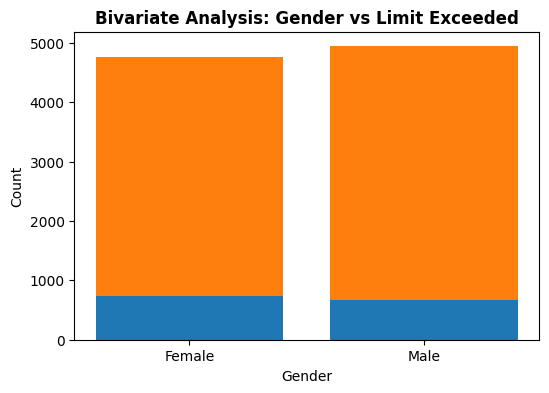

In [46]:
cross_tab = pd.crosstab(df["Gender"], df["Exceeded_Recommended_Limit"])

labels = cross_tab.index
values = cross_tab.values

bottom = np.zeros(len(labels))

plt.figure(figsize=(6,4))
for i in range(values.shape[1]):
    plt.bar(labels, values[:, i], bottom=bottom)
    bottom += values[:, i]

plt.title("Bivariate Analysis: Gender vs Limit Exceeded", fontweight='bold')
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

### 🔍 Insight:
- Both male and female students show similar proportions of exceeding screen time limits.
- No strong gender-based difference is observed in excessive usage behavior.

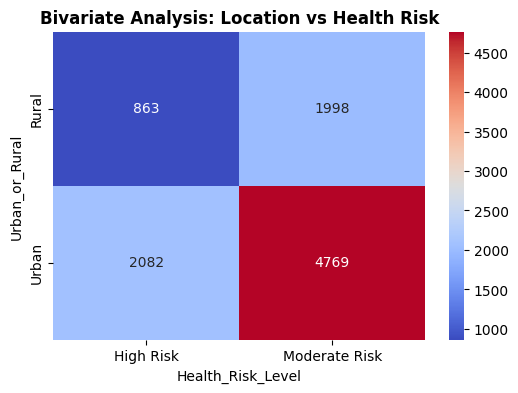

In [47]:
cross_tab = pd.crosstab(df["Urban_or_Rural"], df["Health_Risk_Level"])

plt.figure(figsize=(6,4))
sns.heatmap(cross_tab, annot=True, fmt="d", cmap="coolwarm")
plt.title("Bivariate Analysis: Location vs Health Risk", fontweight='bold')
plt.show()

### 🔍 Insight:
- Both male and female students show similar proportions of exceeding screen time limits.
- No strong gender-based difference is observed in excessive usage behavior.

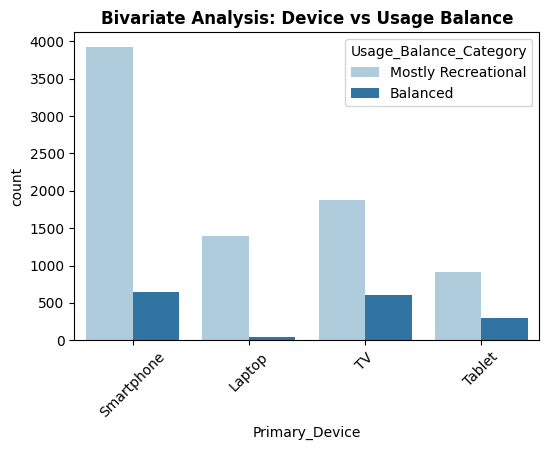

In [48]:
plt.figure(figsize=(6,4))
sns.countplot(x=df["Primary_Device"], hue=df["Usage_Balance_Category"], palette="Paired")
plt.title("Bivariate Analysis: Device vs Usage Balance", fontweight='bold')
plt.xticks(rotation=45)
plt.show()

### 🔍 Insight:
- Most students across all devices fall under "Mostly Recreational" usage.
- Smartphones dominate recreational usage significantly.
- Balanced usage is relatively lower across all device types.

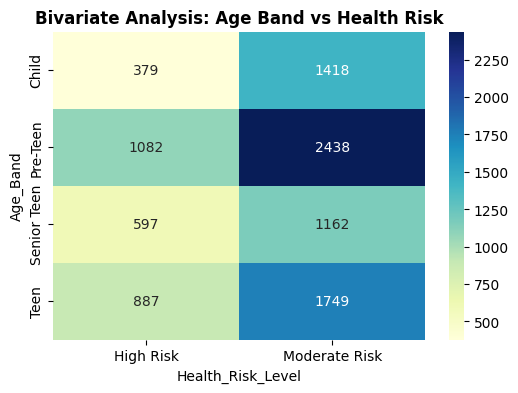

In [49]:
cross_tab = pd.crosstab(df["Age_Band"], df["Health_Risk_Level"])

plt.figure(figsize=(6,4))
sns.heatmap(cross_tab, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Bivariate Analysis: Age Band vs Health Risk", fontweight='bold')
plt.show()

### 🔍 Insight:
- Health risk levels vary across age groups, with moderate risk being more common.
- Certain age groups (like teens) show higher concentration in risk categories.
- This indicates potential age-related patterns in screen-related health impact.

## **Cohort Analysis**

In [10]:
#   Cohort Analysis

cohort = pd.crosstab(df['Age_Band'], df['Device_Type_Category'])

print(cohort)

Device_Type_Category  Other  Portable
Age_Band                             
Child                   683      1114
Pre-Teen                895      2625
Senior Teen             366      1393
Teen                    543      2093


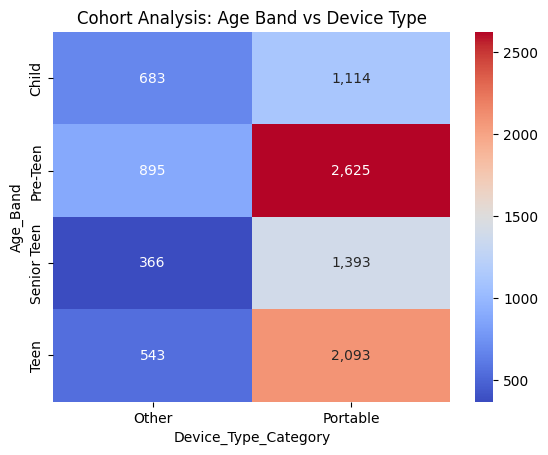

In [11]:
#   Age Band vs Device Type

cohort = pd.crosstab(df['Age_Band'], df['Device_Type_Category'])

sns.heatmap(cohort, annot=True, cmap='coolwarm', fmt=',')

plt.title("Cohort Analysis: Age Band vs Device Type")
plt.show()

### Key Insights

- Portable devices dominate across all age groups  
- Pre-Teens show the highest usage  
- Teens also have high screen dependency  

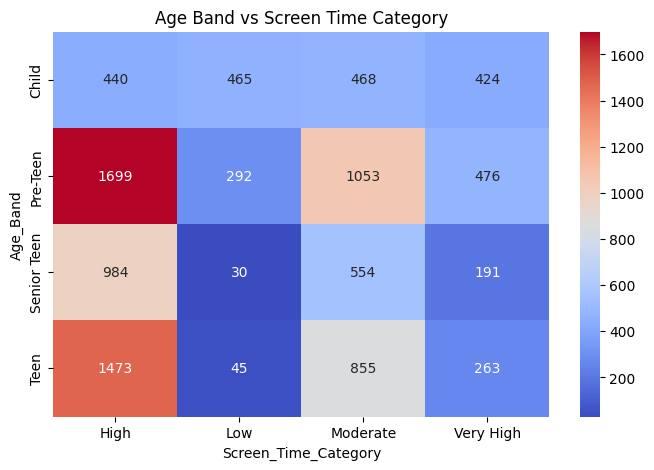

In [9]:
# Age Band vs Screen Time Category

cohort_screen = pd.crosstab(df["Age_Band"], df["Screen_Time_Category"])
plt.figure(figsize=(8,5))
sns.heatmap(cohort_screen, annot=True, cmap="coolwarm", fmt="d")
plt.title("Age Band vs Screen Time Category")
plt.show()

### Key Insights

- Portable devices dominate across all age groups  
- Pre-Teens show the highest usage  
- Teens also have high screen dependency  

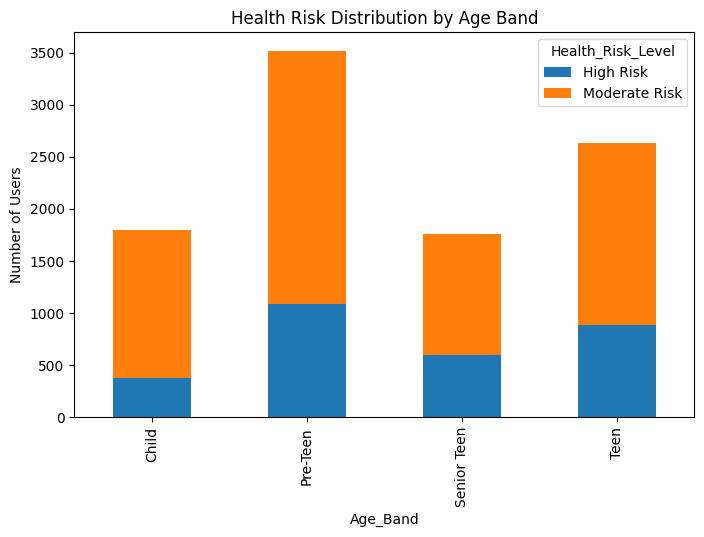

In [10]:
# Health Risk by Age Band

health_age = pd.crosstab(df["Age_Band"], df["Health_Risk_Level"])

health_age.plot(kind="bar", stacked=True, figsize=(8,5))
plt.title("Health Risk Distribution by Age Band")
plt.ylabel("Number of Users")
plt.show()

### Key Insights

- **Pre-Teens exhibit the highest accumulation of health risks**, both moderate and high, compared to other groups.  
- **Teens show a strong presence of high-risk cases**, indicating prolonged exposure effects.  
- **Children maintain a lower proportion of high-risk cases**, suggesting protective factors like parental control.  
- **Senior Teens show a more stable distribution**, possibly indicating adaptation or controlled usage patterns.

### Interpretation

- Health risks are not just increasing with age but are **most concentrated during early adolescence**, making it a sensitive stage for intervention.

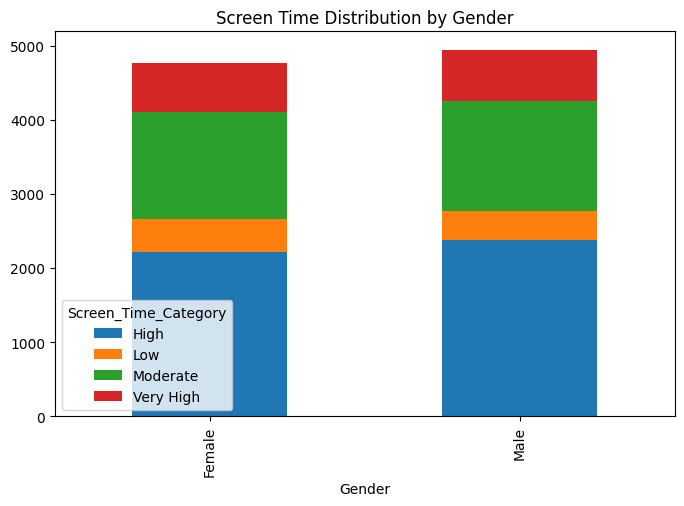

In [13]:
#  Screen Time by Gender

gender_screen = pd.crosstab(df["Gender"], df["Screen_Time_Category"])

gender_screen.plot(kind="bar", stacked=True, figsize=(8,5))
plt.title("Screen Time Distribution by Gender")
plt.show()

### Key Insights

- **Male users slightly dominate in extreme screen time categories**, particularly in high usage segments.  
- **Female users show a more balanced distribution across moderate and high categories**.  
- **Low usage remains minimal for both genders**, indicating widespread screen engagement.

### Interpretation

- While overall patterns are similar, **male users tend to lean more toward intensive usage**, whereas females show relatively **distributed usage behavior**.

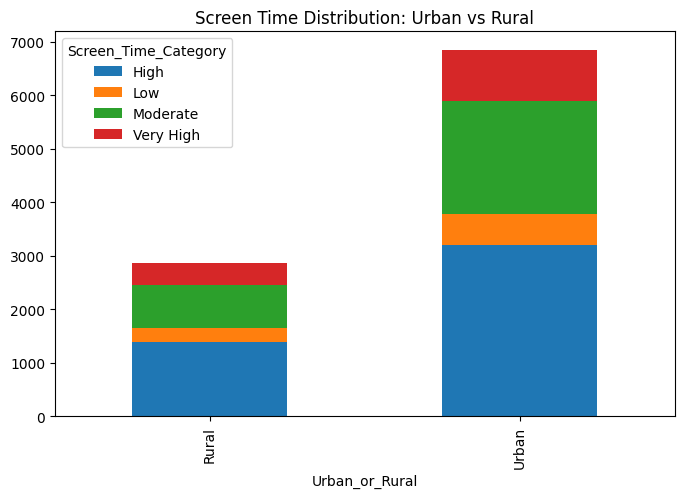

In [12]:
#Screen Time Urban vs Rural

urban_screen = pd.crosstab(df["Urban_or_Rural"], df["Screen_Time_Category"])

urban_screen.plot(kind="bar", stacked=True, figsize=(8,5))
plt.title("Screen Time Distribution: Urban vs Rural")
plt.show()

### Key Insights

- **Urban users dominate in every screen time category**, showing a significantly larger digital footprint.  
- **High and moderate usage form the majority in urban areas**, indicating frequent engagement.  
- **Rural users, though fewer, still reflect a growing presence in moderate usage levels**.

### Interpretation

- The gap between urban and rural usage highlights **access-driven behavior**, where availability of technology directly influences screen habits.

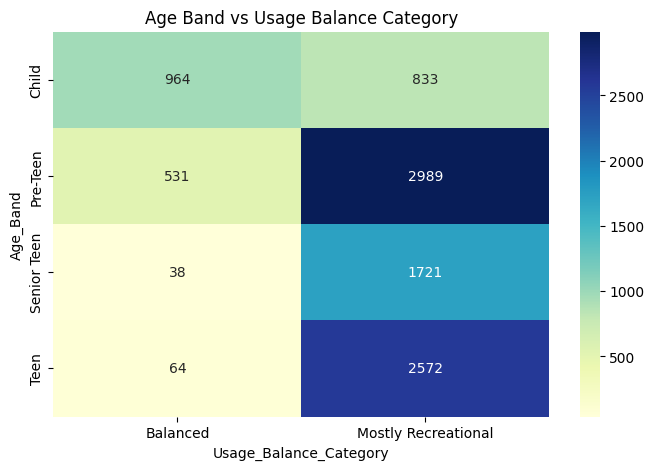

In [14]:
# Age Band x Usage Balance Category

usage_cohort = pd.crosstab(df["Age_Band"], df["Usage_Balance_Category"])

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.heatmap(usage_cohort, annot=True, cmap="YlGnBu", fmt="d")
plt.title("Age Band vs Usage Balance Category")
plt.show()

### Key Insights

- **Recreational usage overwhelmingly dominates across all age groups**, especially in Pre-Teens and Teens.  
- **Balanced usage is most visible in children**, but declines sharply with age.  
- **Senior Teens show minimal balanced behavior**, indicating a strong shift toward entertainment.

### Interpretation

- There is a clear behavioral shift from **structured usage to entertainment-focused consumption** as children grow older.

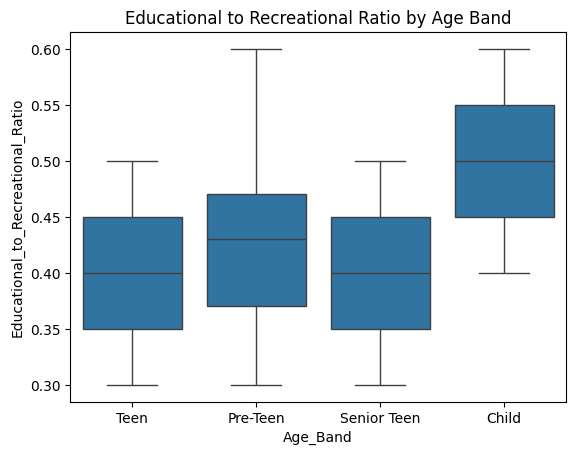

In [15]:
# Educational to Recreational Ratio by Age band

sns.boxplot(x="Age_Band", y="Educational_to_Recreational_Ratio", data=df)
plt.title("Educational to Recreational Ratio by Age Band")
plt.show()

### Key Insights

- **Children maintain the highest educational proportion**, reflecting guided or academic usage.  
- **Teen groups show reduced ratios**, indicating increasing preference for recreational content.  
- **Pre-Teens display variability**, suggesting a transition phase between controlled and independent usage.

### Interpretation

- The gradual decline in educational ratio highlights a **shift in purpose of screen usage from learning to leisure**.

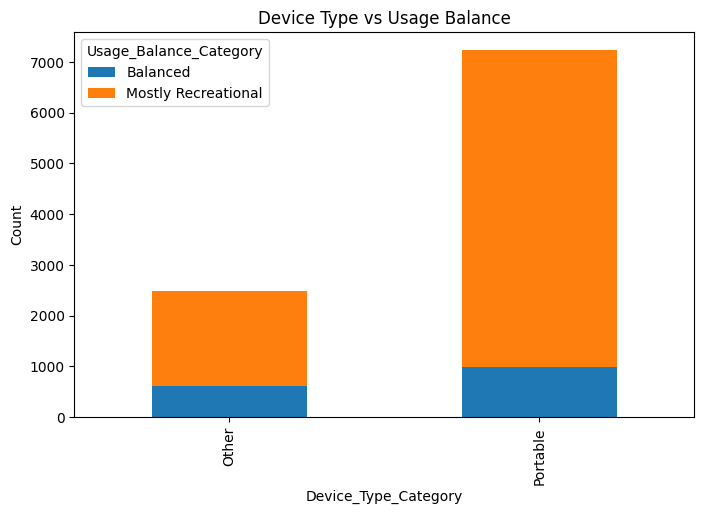

In [16]:
#  Device Type vs Usage Balance
device_usage = pd.crosstab(df["Device_Type_Category"], df["Usage_Balance_Category"])

device_usage.plot(kind="bar", stacked=True, figsize=(8,5))
plt.title("Device Type vs Usage Balance")
plt.ylabel("Count")
plt.show()

### Key Insights

- **Portable devices are strongly linked with recreational usage**, dominating the entertainment segment.  
- **Balanced usage is comparatively low across both device types**, but slightly better in non-portable devices.  
- **Other devices show less extreme behavior**, indicating more controlled usage patterns.

### Interpretation

- Mobility and accessibility of portable devices encourage **frequent and entertainment-driven engagement**.

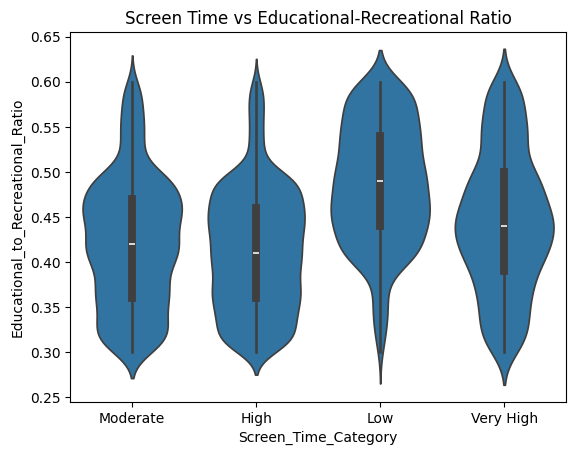

In [17]:
# Screen Time Category vs Educational-Recreational Ratio

sns.violinplot(x="Screen_Time_Category",
               y="Educational_to_Recreational_Ratio",
               data=df)

plt.title("Screen Time vs Educational-Recreational Ratio")
plt.show()

### Key Insights

- **Users with lower screen time tend to maintain a higher educational ratio**, indicating purposeful usage.  
- **As screen time increases, the ratio becomes more centered and slightly declines**, showing reduced educational focus.  
- **Very high usage groups show variability**, but lean toward entertainment-heavy behavior.

### Interpretation

- Increased screen duration does not proportionally increase educational usage, suggesting **excess usage is largely recreational**.

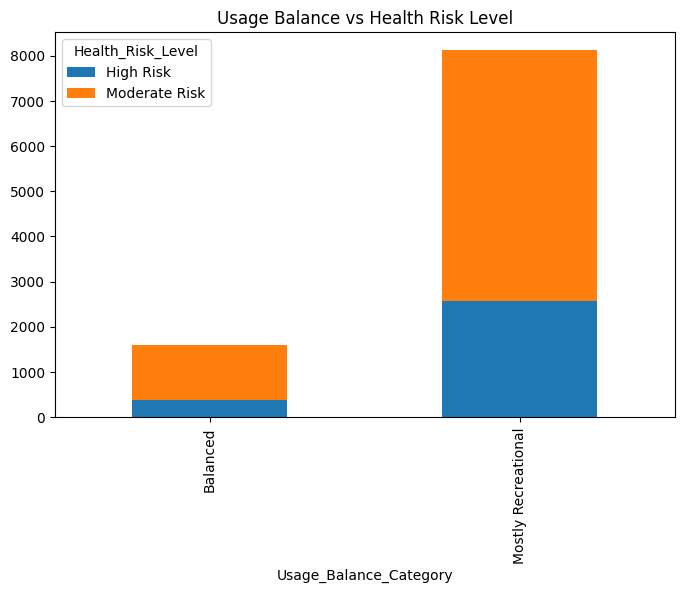

In [18]:
# Health Risk and Usage Balance

risk_usage = pd.crosstab(df["Usage_Balance_Category"], df["Health_Risk_Level"])

risk_usage.plot(kind="bar", stacked=True, figsize=(8,5))
plt.title("Usage Balance vs Health Risk Level")
plt.show()

### Key Insights

- **Recreational-heavy users account for the majority of both moderate and high-risk cases**.  
- **Balanced users contribute significantly fewer high-risk cases**, indicating safer usage patterns.  
- The gap between balanced and recreational users is **substantial in health outcomes**.

### Interpretation

- Usage behavior plays a critical role in health impact, where **entertainment-dominant usage significantly elevates risk levels**.

## **Segment Analysis**

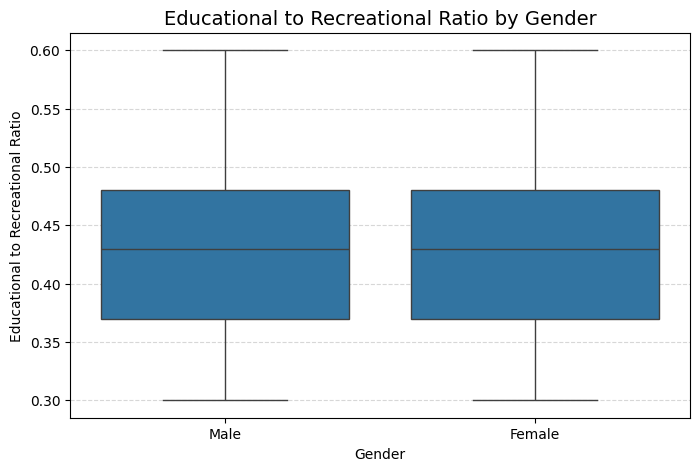

In [13]:
##     Segment Analysis

# Educational to Recreational Ratio by Gender

plt.figure(figsize=(8,5))

sns.boxplot(
    x="Gender",
    y="Educational_to_Recreational_Ratio",
    data=df
)

plt.title("Educational to Recreational Ratio by Gender", fontsize=14)
plt.xlabel("Gender")
plt.ylabel("Educational to Recreational Ratio")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

### Key Insights

- **Both genders show nearly identical median ratios**, indicating similar usage behavior.  
- **The spread of values is also very similar**, suggesting consistent patterns across male and female users.  
- No extreme skewness is observed in either group.

### Interpretation

- Educational vs recreational usage is **not significantly influenced by gender**, showing a uniform behavioral trend.

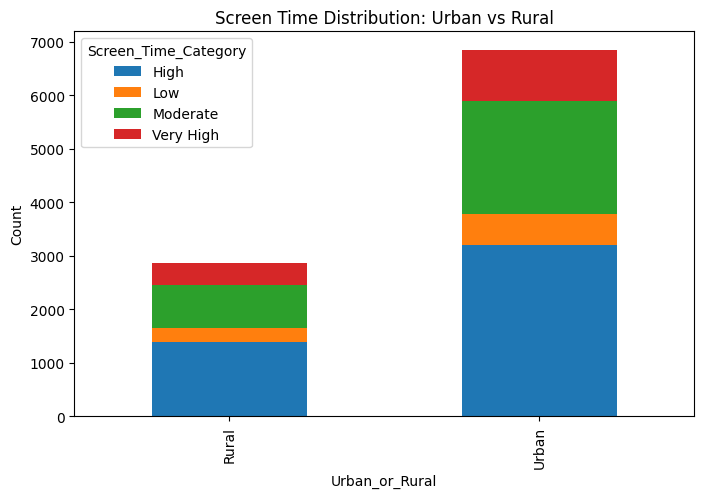

In [20]:
#Urban vs Rural Screen Time

urban_segment = pd.crosstab(df["Urban_or_Rural"], df["Screen_Time_Category"])

urban_segment.plot(kind="bar", stacked=True, figsize=(8,5))

plt.title("Screen Time Distribution: Urban vs Rural")
plt.ylabel("Count")
plt.show()

### Key Insights

- **Urban users dominate high and moderate screen time categories**, forming the largest share of total usage.  
- **Rural users have lower overall engagement**, but follow a similar distribution pattern.  
- The structure of usage is similar, but the **scale differs significantly**.

### Interpretation

- The difference lies not in behavior but in **volume of usage**, driven by accessibility and lifestyle differences.

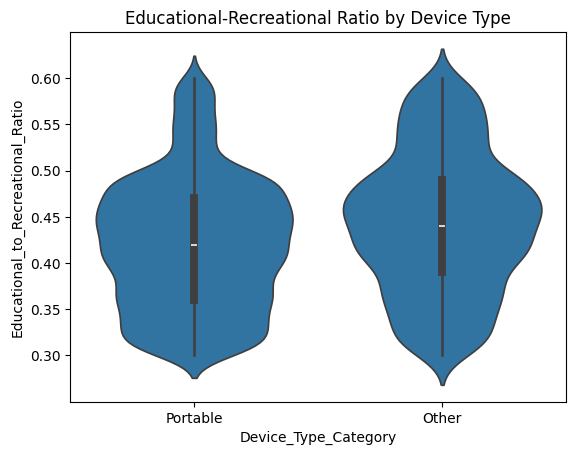

In [21]:
# Device Type vs Educational-Recreational Ratio

sns.violinplot(x="Device_Type_Category",
               y="Educational_to_Recreational_Ratio",
               data=df)

plt.title("Educational-Recreational Ratio by Device Type")
plt.show()

### Key Insights

- **Both device types show a similar central tendency**, but variation is slightly higher in portable devices.  
- **Portable devices show more spread toward lower ratios**, indicating higher recreational usage in some users.  
- Other devices maintain a relatively **stable distribution**.

### Interpretation

- Device type slightly influences usage behavior, where **portable devices allow more flexible and entertainment-driven usage**.

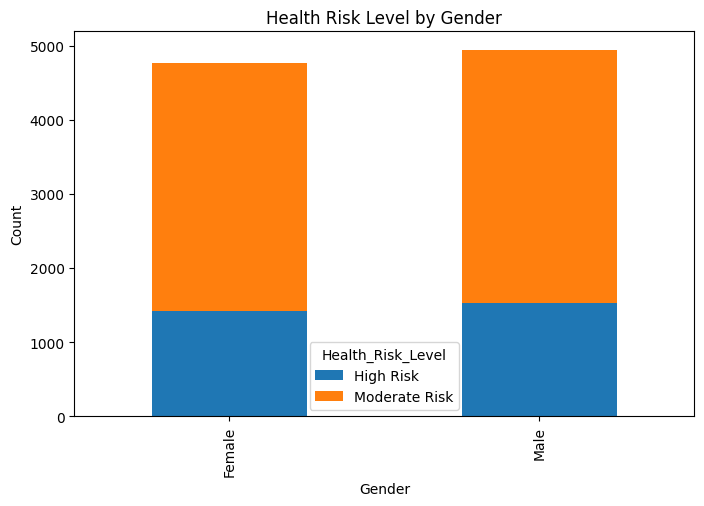

In [22]:
# Gender vs Health Risk Level

gender_health = pd.crosstab(df["Gender"], df["Health_Risk_Level"])

gender_health.plot(kind="bar", stacked=True, figsize=(8,5))

plt.title("Health Risk Level by Gender")
plt.ylabel("Count")
plt.show()

### Key Insights

- **Both genders show comparable levels of moderate and high health risks**.  
- **Male users have a slightly higher count in high-risk category**, but the difference is marginal.  
- Moderate risk dominates for both genders.

### Interpretation

- Health risks related to screen usage are **largely consistent across genders**, indicating shared exposure patterns.

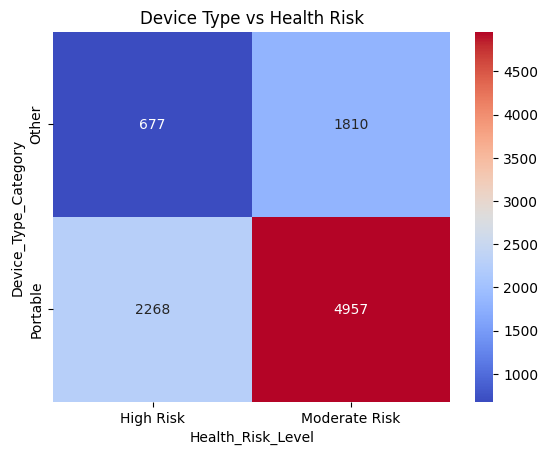

In [24]:
## Device Type vs Health Risk

sns.scatterplot(x="Educational_Time_hr",
                y="Recreational_Time_hr",
                hue="Urban_or_Rural",
                data=df)

plt.title("Educational vs Recreational Screen Time by Location")
plt.show()

### Key Insights

- **Portable device users account for a significantly higher number of both moderate and high-risk cases**.  
- **Other device users show much lower health risk counts** in comparison.  
- The gap between device types is substantial.

### Interpretation

- Portable devices contribute heavily to **increased health risks**, likely due to prolonged and frequent usage.